# PX4 Phase 1 Rate Dynamics PINN Training v9 Hybrid Residual

v9 combines the two useful ideas from previous runs:

- v8 physics core: predict acceleration/angular acceleration and integrate it into a physically meaningful `dx`.
- v7 flexibility: add a small bounded residual `dx` head so PX4 controller lag, estimator bias, sampling jitter, and hover-thrust drift can be learned from data.

Runtime model contract:

```text
x_t, u_t, prev_u_t, du_t, dt_s -> dx_t
```

Internal prediction:

```text
core = [a_n, a_e, a_d, p_dot, q_dot, r_dot]
physics_dx = integrate(core, x_t, dt_s)
residual_dx = bounded neural correction
final_dx = physics_dx + residual_dx
```

This should be less brittle than v8 and more rollout-stable than pure direct-delta learning.


In [1]:
# Colab setup
from pathlib import Path
import json
import math
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device: cuda
torch: 2.10.0+cu128


In [2]:
# Dataset path
# Prefer v4 filtered dataset. Set manually if needed.
DATASET_DIR = ''  # e.g. '/content/drive/MyDrive/px4_datasets/processed/px4_phase1_rate_dynamics_dataset_v4_filtered_imu_aux_20260508_180000'

def find_latest_dataset_dir():
    import glob
    patterns = [
        '/content/drive/MyDrive/**/px4_phase1_rate_dynamics_dataset_v4_filtered_imu_aux_*',
        '/content/**/px4_phase1_rate_dynamics_dataset_v4_filtered_imu_aux_*',
        './px4_phase1_rate_dynamics_dataset_v4_filtered_imu_aux_*',
        '/content/drive/MyDrive/**/px4_phase1_rate_dynamics_dataset_v3_imu_aux_*',
    ]
    matches=[]
    for pat in patterns:
        matches.extend(glob.glob(pat, recursive=True))
    matches=sorted(set(matches))
    matches=[Path(m) for m in matches if (Path(m)/'train.csv').exists()]
    if not matches:
        raise FileNotFoundError('No v4/v3 processed dataset found. Set DATASET_DIR manually.')
    return matches[-1]

DATASET_PATH = Path(DATASET_DIR) if DATASET_DIR else find_latest_dataset_dir()
print('DATASET_PATH:', DATASET_PATH)
print('files:', sorted([p.name for p in DATASET_PATH.iterdir()])[:20])


DATASET_PATH: /content/drive/MyDrive/px4_datasets/processed/px4_phase1_rate_dynamics_dataset_v4_filtered_imu_aux_20260508_175455
files: ['all_samples.csv', 'dataset_summary.csv', 'filter_report.csv', 'metadata.json', 'source_summary.csv', 'test.csv', 'train.csv', 'val.csv']


In [3]:
# Load data and define columns
base_train = pd.read_csv(DATASET_PATH / 'train.csv')
base_val = pd.read_csv(DATASET_PATH / 'val.csv')
base_test = pd.read_csv(DATASET_PATH / 'test.csv')
all_df = pd.read_csv(DATASET_PATH / 'all_samples.csv') if (DATASET_PATH / 'all_samples.csv').exists() else pd.concat([base_train, base_val, base_test], ignore_index=True)

metadata = {}
if (DATASET_PATH / 'metadata.json').exists():
    metadata = json.loads((DATASET_PATH / 'metadata.json').read_text())

state_cols = metadata.get('state_cols') or [c.removeprefix('dx_') for c in all_df.columns if c.startswith('dx_')]
action_cols = metadata.get('action_cols') or [c.removeprefix('u_') for c in all_df.columns if c.startswith('u_')]
feature_cols = [f'x_{c}' for c in state_cols] + [f'u_{c}' for c in action_cols] + [f'prev_u_{c}' for c in action_cols] + [f'du_{c}' for c in action_cols] + ['dt_s']
target_cols = [f'dx_{c}' for c in state_cols]
next_cols = [f'x_next_{c}' for c in state_cols]
core_cols = [
    'aux_derived_accel_north_m_s2',
    'aux_derived_accel_east_m_s2',
    'aux_derived_accel_down_m_s2',
    'aux_derived_roll_accel_rad_s2',
    'aux_derived_pitch_accel_rad_s2',
    'aux_derived_yaw_accel_rad_s2',
]
missing = [c for c in feature_cols + target_cols + next_cols + core_cols if c not in all_df.columns]
if missing:
    raise ValueError(f'Missing columns: {missing}')

needed = feature_cols + target_cols + next_cols + core_cols
all_df = all_df[np.isfinite(all_df[needed].to_numpy(np.float32)).all(axis=1)].copy()

# Use processed split from v4. It includes partial N11 train/val/test split.
if 'split' in all_df.columns:
    train_df = all_df[all_df['split'].eq('train')].copy()
    val_df = all_df[all_df['split'].eq('val')].copy()
    test_df = all_df[all_df['split'].eq('test')].copy()
else:
    rng = np.random.default_rng(SEED)
    idx = all_df.index.to_numpy(); rng.shuffle(idx)
    n=len(idx); n_train=int(0.72*n); n_val=int(0.14*n)
    train_df=all_df.loc[idx[:n_train]].copy(); val_df=all_df.loc[idx[n_train:n_train+n_val]].copy(); test_df=all_df.loc[idx[n_train+n_val:]].copy()

print('train/val/test rows:', len(train_df), len(val_df), len(test_df))
print('state_cols:', state_cols)
print('action_cols:', action_cols)
print('core_cols:', core_cols)
print('n_features:', len(feature_cols), 'n_state_targets:', len(target_cols), 'n_core:', len(core_cols))
if 'scenario' in all_df.columns:
    split_view=pd.concat([train_df.assign(split_view='train'), val_df.assign(split_view='val'), test_df.assign(split_view='test')])
    display(split_view.groupby(['split_view','scenario']).size().to_frame('rows').reset_index())


train/val/test rows: 12054 2344 2849
state_cols: ['relative_altitude_m', 'vel_north_m_s', 'vel_east_m_s', 'vel_down_m_s', 'roll_deg', 'pitch_deg', 'yaw_deg', 'roll_rate_rad_s', 'pitch_rate_rad_s', 'yaw_rate_rad_s']
action_cols: ['ref_roll_rate_rad_s', 'ref_pitch_rate_rad_s', 'ref_yaw_rate_rad_s', 'ref_thrust']
core_cols: ['aux_derived_accel_north_m_s2', 'aux_derived_accel_east_m_s2', 'aux_derived_accel_down_m_s2', 'aux_derived_roll_accel_rad_s2', 'aux_derived_pitch_accel_rad_s2', 'aux_derived_yaw_accel_rad_s2']
n_features: 23 n_state_targets: 10 n_core: 6


,split_view,scenario,rows
0,test,N00_hover_hold_0p5192,182
1,test,N01_pitch_rate_doublet_5dps,191
2,test,N02_pitch_rate_doublet_10dps,188
3,test,N03_roll_rate_doublet_5dps,177
4,test,N04_roll_rate_doublet_10dps,193
5,test,N05_yaw_rate_doublet_10dps,200
6,test,N06_yaw_rate_doublet_20dps,294
7,test,N07_thrust_step_pm010,202
8,test,N08_thrust_step_pm020,184
9,test,N09_pitch_thrust_coupled,175


In [4]:
# Scalers and dataloaders
class StandardScaler:
    def __init__(self, mean, std):
        self.mean=np.asarray(mean,dtype=np.float32)
        self.std=np.asarray(std,dtype=np.float32)
        self.std=np.where(self.std<1e-8,1.0,self.std)
    @classmethod
    def fit(cls, arr): return cls(np.nanmean(arr,axis=0), np.nanstd(arr,axis=0))
    def transform(self, arr): return (np.asarray(arr,dtype=np.float32)-self.mean)/self.std
    def inverse_transform(self, arr): return np.asarray(arr,dtype=np.float32)*self.std+self.mean
    def to_dict(self, columns): return {'columns':list(columns),'mean':self.mean.tolist(),'std':self.std.tolist()}

X_train_raw=train_df[feature_cols].to_numpy(np.float32); C_train_raw=train_df[core_cols].to_numpy(np.float32); Y_train_raw=train_df[target_cols].to_numpy(np.float32)
X_val_raw=val_df[feature_cols].to_numpy(np.float32); C_val_raw=val_df[core_cols].to_numpy(np.float32); Y_val_raw=val_df[target_cols].to_numpy(np.float32)
X_test_raw=test_df[feature_cols].to_numpy(np.float32); C_test_raw=test_df[core_cols].to_numpy(np.float32); Y_test_raw=test_df[target_cols].to_numpy(np.float32)

x_scaler=StandardScaler.fit(X_train_raw)
core_scaler=StandardScaler.fit(C_train_raw)
y_scaler=StandardScaler.fit(Y_train_raw)

X_train=x_scaler.transform(X_train_raw); C_train=core_scaler.transform(C_train_raw); Y_train=y_scaler.transform(Y_train_raw)
X_val=x_scaler.transform(X_val_raw); C_val=core_scaler.transform(C_val_raw); Y_val=y_scaler.transform(Y_val_raw)
X_test=x_scaler.transform(X_test_raw); C_test=core_scaler.transform(C_test_raw); Y_test=y_scaler.transform(Y_test_raw)

BATCH_SIZE=1024
train_loader=DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(C_train), torch.tensor(Y_train)), batch_size=BATCH_SIZE, shuffle=True)
val_loader=DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(C_val), torch.tensor(Y_val)), batch_size=BATCH_SIZE, shuffle=False)

x_mean_t=torch.tensor(x_scaler.mean,dtype=torch.float32,device=device); x_std_t=torch.tensor(x_scaler.std,dtype=torch.float32,device=device)
core_mean_t=torch.tensor(core_scaler.mean,dtype=torch.float32,device=device); core_std_t=torch.tensor(core_scaler.std,dtype=torch.float32,device=device)
y_mean_t=torch.tensor(y_scaler.mean,dtype=torch.float32,device=device); y_std_t=torch.tensor(y_scaler.std,dtype=torch.float32,device=device)
feature_index={c:i for i,c in enumerate(feature_cols)}; target_index={c:i for i,c in enumerate(target_cols)}; core_index={c:i for i,c in enumerate(core_cols)}
print('batches:', len(train_loader), len(val_loader))


batches: 12 3


In [5]:
# Hybrid residual model
class HybridResidualMLP(nn.Module):
    def __init__(self, n_in, n_core, n_dx, hidden=512, depth=5, dropout=0.02):
        super().__init__()
        layers=[]; last=n_in
        for _ in range(depth):
            layers += [nn.Linear(last,hidden), nn.SiLU(), nn.LayerNorm(hidden)]
            if dropout>0: layers.append(nn.Dropout(dropout))
            last=hidden
        self.trunk=nn.Sequential(*layers)
        self.core_head=nn.Linear(last,n_core)
        self.residual_head=nn.Linear(last,n_dx)
    def forward(self,x):
        z=self.trunk(x)
        return self.core_head(z), self.residual_head(z)

MODEL_CONFIG=dict(hidden=512, depth=5, dropout=0.02)
model=HybridResidualMLP(len(feature_cols), len(core_cols), len(target_cols), **MODEL_CONFIG).to(device)
print(model)
print('parameters:', sum(p.numel() for p in model.parameters()))


HybridResidualMLP(
  (trunk): Sequential(
    (0): Linear(in_features=23, out_features=512, bias=True)
    (1): SiLU()
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.02, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): SiLU()
    (6): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (7): Dropout(p=0.02, inplace=False)
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): SiLU()
    (10): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (11): Dropout(p=0.02, inplace=False)
    (12): Linear(in_features=512, out_features=512, bias=True)
    (13): SiLU()
    (14): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (15): Dropout(p=0.02, inplace=False)
    (16): Linear(in_features=512, out_features=512, bias=True)
    (17): SiLU()
    (18): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (19): Dropout(p=0.02, inplace=False)
  )
  (core_head): Linear(in_features=512, o

In [6]:
# Physics integration and bounded residuals
ANGLE_RESID_SCALE_DEG = 0.12
RATE_RESID_SCALE_RAD_S = 0.012
VEL_RESID_SCALE_M_S = 0.035
ALT_RESID_SCALE_M = 0.035

CORE_DATA_WEIGHT = 0.35
FINAL_DX_WEIGHT = 1.00
PHYSICS_DX_WEIGHT = 0.18
RESIDUAL_REG_WEIGHT = 0.025

# Residual limits are deliberately small: enough to absorb PX4 lag/bias, not enough
# to ignore the physics core.
RESIDUAL_LIMITS = {
    'dx_relative_altitude_m': 0.030,
    'dx_vel_north_m_s': 0.020,
    'dx_vel_east_m_s': 0.020,
    'dx_vel_down_m_s': 0.018,
    'dx_roll_deg': 0.060,
    'dx_pitch_deg': 0.060,
    'dx_yaw_deg': 0.120,
    'dx_roll_rate_rad_s': 0.006,
    'dx_pitch_rate_rad_s': 0.006,
    'dx_yaw_rate_rad_s': 0.004,
}
resid_limit_t=torch.tensor([RESIDUAL_LIMITS[c] for c in target_cols],dtype=torch.float32,device=device)

core_weight_vec=torch.ones(len(core_cols),dtype=torch.float32,device=device)
for name,w in {'aux_derived_accel_down_m_s2':1.20,'aux_derived_yaw_accel_rad_s2':1.15}.items():
    if name in core_index: core_weight_vec[core_index[name]]=w

def raw_feature(xb,name):
    i=feature_index[name]; return xb[:,i]*x_std_t[i]+x_mean_t[i]
def raw_core(core_scaled,name):
    i=core_index[name]; return core_scaled[:,i]*core_std_t[i]+core_mean_t[i]
def wrap_rad(a): return torch.atan2(torch.sin(a), torch.cos(a))
def wrap_deg_t(a): return torch.rad2deg(wrap_rad(torch.deg2rad(a)))

def smooth_l1_scaled(pred,target,weight_vec,beta=0.5):
    err=pred-target; ae=torch.abs(err)
    loss=torch.where(ae<beta,0.5*err**2/beta,ae-0.5*beta)
    return torch.mean(loss*weight_vec[None,:])

def integrate_dx(xb, core_scaled):
    dt=raw_feature(xb,'dt_s').clamp_min(1e-4)
    h=raw_feature(xb,'x_relative_altitude_m')
    vn=raw_feature(xb,'x_vel_north_m_s'); ve=raw_feature(xb,'x_vel_east_m_s'); vd=raw_feature(xb,'x_vel_down_m_s')
    roll=raw_feature(xb,'x_roll_deg'); pitch=raw_feature(xb,'x_pitch_deg'); yaw=raw_feature(xb,'x_yaw_deg')
    p=raw_feature(xb,'x_roll_rate_rad_s'); q=raw_feature(xb,'x_pitch_rate_rad_s'); r=raw_feature(xb,'x_yaw_rate_rad_s')
    an=raw_core(core_scaled,'aux_derived_accel_north_m_s2')
    ae=raw_core(core_scaled,'aux_derived_accel_east_m_s2')
    ad=raw_core(core_scaled,'aux_derived_accel_down_m_s2')
    pdot=raw_core(core_scaled,'aux_derived_roll_accel_rad_s2')
    qdot=raw_core(core_scaled,'aux_derived_pitch_accel_rad_s2')
    rdot=raw_core(core_scaled,'aux_derived_yaw_accel_rad_s2')
    vn_next=vn+an*dt; ve_next=ve+ae*dt; vd_next=vd+ad*dt
    h_next=h-0.5*(vd+vd_next)*dt
    p_next=p+pdot*dt; q_next=q+qdot*dt; r_next=r+rdot*dt
    phi=torch.deg2rad(roll); theta=torch.deg2rad(pitch).clamp(-1.2,1.2)
    tan_theta=torch.tan(theta); cos_theta=torch.cos(theta).clamp_min(0.2)
    sin_phi=torch.sin(phi); cos_phi=torch.cos(phi)
    p_mid=0.5*(p+p_next); q_mid=0.5*(q+q_next); r_mid=0.5*(r+r_next)
    phi_dot=p_mid+tan_theta*(q_mid*sin_phi+r_mid*cos_phi)
    theta_dot=q_mid*cos_phi-r_mid*sin_phi
    psi_dot=(q_mid*sin_phi+r_mid*cos_phi)/cos_theta
    roll_next=roll+torch.rad2deg(phi_dot*dt)
    pitch_next=pitch+torch.rad2deg(theta_dot*dt)
    yaw_next=yaw+torch.rad2deg(psi_dot*dt)
    pred_dx={
        'dx_relative_altitude_m': h_next-h,
        'dx_vel_north_m_s': vn_next-vn,
        'dx_vel_east_m_s': ve_next-ve,
        'dx_vel_down_m_s': vd_next-vd,
        'dx_roll_deg': roll_next-roll,
        'dx_pitch_deg': pitch_next-pitch,
        'dx_yaw_deg': wrap_deg_t(yaw_next-yaw),
        'dx_roll_rate_rad_s': p_next-p,
        'dx_pitch_rate_rad_s': q_next-q,
        'dx_yaw_rate_rad_s': r_next-r,
    }
    return torch.stack([pred_dx[c] for c in target_cols], dim=1)

def bounded_residual(resid_scaled):
    # residual_head is in roughly normalized units; tanh bounds it in physical units.
    return torch.tanh(resid_scaled) * resid_limit_t[None,:]

def dx_loss(pred_dx_raw, y_scaled):
    y_raw=y_scaled*y_std_t[None,:]+y_mean_t[None,:]
    losses=[]
    for name,scale,weight in [
        ('dx_relative_altitude_m',ALT_RESID_SCALE_M,1.10),
        ('dx_vel_north_m_s',VEL_RESID_SCALE_M_S,0.85),
        ('dx_vel_east_m_s',VEL_RESID_SCALE_M_S,0.85),
        ('dx_vel_down_m_s',VEL_RESID_SCALE_M_S,1.00),
        ('dx_roll_deg',ANGLE_RESID_SCALE_DEG,1.15),
        ('dx_pitch_deg',ANGLE_RESID_SCALE_DEG,1.15),
        ('dx_yaw_deg',ANGLE_RESID_SCALE_DEG,1.10),
        ('dx_roll_rate_rad_s',RATE_RESID_SCALE_RAD_S,1.10),
        ('dx_pitch_rate_rad_s',RATE_RESID_SCALE_RAD_S,1.10),
        ('dx_yaw_rate_rad_s',RATE_RESID_SCALE_RAD_S,1.05),
    ]:
        j=target_index[name]
        err=pred_dx_raw[:,j]-y_raw[:,j]
        if name=='dx_yaw_deg': err=wrap_deg_t(err)
        losses.append(weight*torch.mean((err/scale)**2))
    return torch.stack(losses).mean()


epoch 0001 train=0.3254 val=0.1703 final=0.0885 phys=0.0404 core=0.2076 resid=0.0714 best=0.1703@1
epoch 0025 train=0.0626 val=0.0680 final=0.0158 phys=0.0220 core=0.1373 resid=0.0061 best=0.0680@25
epoch 0050 train=0.0585 val=0.0677 final=0.0162 phys=0.0233 core=0.1348 resid=0.0075 best=0.0674@47
epoch 0075 train=0.0574 val=0.0669 final=0.0161 phys=0.0233 core=0.1328 resid=0.0080 best=0.0666@56
epoch 0100 train=0.0553 val=0.0679 final=0.0164 phys=0.0239 core=0.1343 resid=0.0084 best=0.0666@56
epoch 0125 train=0.0549 val=0.0671 final=0.0158 phys=0.0234 core=0.1338 resid=0.0084 best=0.0664@121
epoch 0150 train=0.0538 val=0.0674 final=0.0158 phys=0.0235 core=0.1345 resid=0.0093 best=0.0664@121
epoch 0175 train=0.0523 val=0.0679 final=0.0160 phys=0.0239 core=0.1352 resid=0.0100 best=0.0664@121
epoch 0200 train=0.0514 val=0.0684 final=0.0163 phys=0.0242 core=0.1358 resid=0.0099 best=0.0664@121
epoch 0225 train=0.0503 val=0.0677 final=0.0152 phys=0.0234 core=0.1373 resid=0.0104 best=0.0664@

,epoch,train_loss,train_final,train_physics,train_core,train_resid,val_loss,val_final,val_physics,val_core,val_resid,lr
256,257,0.049302,0.008726,0.019590,0.105018,0.011750,0.068720,0.015820,0.023822,0.138106,0.010986,0.000832
257,258,0.049260,0.008729,0.019649,0.104858,0.011724,0.068681,0.015725,0.023555,0.138386,0.011274,0.000831
258,259,0.049424,0.008743,0.019645,0.105289,0.011769,0.068367,0.015426,0.023261,0.138504,0.011095,0.000829
259,260,0.049392,0.008796,0.019666,0.105035,0.011752,0.068037,0.015370,0.023336,0.137656,0.011495,0.000828
260,261,0.049193,0.008796,0.019671,0.104457,0.011830,0.069189,0.015936,0.023803,0.139106,0.011253,0.000827


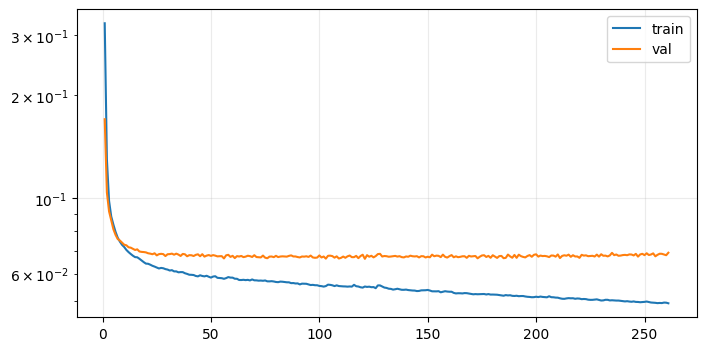

In [7]:
# Training
EPOCHS=950
LR=1e-3
WEIGHT_DECAY=2e-5
PATIENCE=140
GRAD_CLIP=2.0

optimizer=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=EPOCHS,eta_min=1e-5)

def run_epoch(loader, train_mode):
    model.train(train_mode)
    totals={'loss':0.0,'final':0.0,'physics':0.0,'core':0.0,'resid':0.0}; n=0
    for xb, cb, yb in loader:
        xb=xb.to(device); cb=cb.to(device); yb=yb.to(device)
        if train_mode: optimizer.zero_grad(set_to_none=True)
        core_pred,resid_raw=model(xb)
        phys_dx=integrate_dx(xb,core_pred)
        resid_dx=bounded_residual(resid_raw)
        final_dx=phys_dx+resid_dx
        final_loss=dx_loss(final_dx,yb)
        physics_loss=dx_loss(phys_dx,yb)
        core_loss=smooth_l1_scaled(core_pred,cb,core_weight_vec)
        resid_reg=torch.mean((resid_dx/resid_limit_t[None,:])**2)
        loss=FINAL_DX_WEIGHT*final_loss + PHYSICS_DX_WEIGHT*physics_loss + CORE_DATA_WEIGHT*core_loss + RESIDUAL_REG_WEIGHT*resid_reg
        if train_mode:
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),GRAD_CLIP); optimizer.step()
        bs=len(xb); n+=bs
        totals['loss']+=float(loss.detach().cpu())*bs
        totals['final']+=float(final_loss.detach().cpu())*bs
        totals['physics']+=float(physics_loss.detach().cpu())*bs
        totals['core']+=float(core_loss.detach().cpu())*bs
        totals['resid']+=float(resid_reg.detach().cpu())*bs
    return {k:v/max(1,n) for k,v in totals.items()}

best_val=float('inf'); best_state=None; best_epoch=0; wait=0; history=[]; t0=time.time()
for epoch in range(1,EPOCHS+1):
    tr=run_epoch(train_loader,True); va=run_epoch(val_loader,False); scheduler.step()
    row={'epoch':epoch,**{f'train_{k}':v for k,v in tr.items()},**{f'val_{k}':v for k,v in va.items()},'lr':scheduler.get_last_lr()[0]}; history.append(row)
    monitor=va['loss']
    if monitor<best_val:
        best_val=monitor; best_epoch=epoch; wait=0; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    else:
        wait+=1
    if epoch==1 or epoch%25==0:
        print(f"epoch {epoch:04d} train={tr['loss']:.4f} val={va['loss']:.4f} final={va['final']:.4f} phys={va['physics']:.4f} core={va['core']:.4f} resid={va['resid']:.4f} best={best_val:.4f}@{best_epoch}")
    if wait>=PATIENCE:
        print('early stop at',epoch,'best_epoch=',best_epoch); break
if best_state is not None: model.load_state_dict(best_state)
hist_df=pd.DataFrame(history)
print('elapsed min:',round((time.time()-t0)/60,2),'best_epoch:',best_epoch,'best_val:',best_val)
display(hist_df.tail())
fig,ax=plt.subplots(figsize=(8,4)); ax.plot(hist_df['epoch'],hist_df['train_loss'],label='train'); ax.plot(hist_df['epoch'],hist_df['val_loss'],label='val'); ax.set_yscale('log'); ax.grid(True,alpha=.25); ax.legend(); plt.show()


In [8]:
# Metrics
@torch.no_grad()
def predict_dx_core(df):
    x=x_scaler.transform(df[feature_cols].to_numpy(np.float32))
    final_parts=[]; phys_parts=[]; core_parts=[]; resid_parts=[]; model.eval()
    for i in range(0,len(x),4096):
        xb=torch.tensor(x[i:i+4096],dtype=torch.float32,device=device)
        core_scaled,resid_raw=model(xb)
        phys=integrate_dx(xb,core_scaled)
        resid=bounded_residual(resid_raw)
        final=phys+resid
        final_parts.append(final.detach().cpu().numpy())
        phys_parts.append(phys.detach().cpu().numpy())
        resid_parts.append(resid.detach().cpu().numpy())
        core_parts.append((core_scaled*core_std_t[None,:]+core_mean_t[None,:]).detach().cpu().numpy())
    return np.concatenate(final_parts), np.concatenate(phys_parts), np.concatenate(resid_parts), np.concatenate(core_parts)

def metric_table(split,cols,pred,true):
    rows=[]
    for j,c in enumerate(cols):
        err=pred[:,j]-true[:,j]
        if c=='dx_yaw_deg': err=(err+180)%360-180
        rows.append({'split':split,'target':c,'rmse':float(np.sqrt(np.mean(err**2))),'mae':float(np.mean(np.abs(err))),'std_true':float(np.std(true[:,j]))})
    return pd.DataFrame(rows)

parts=[]; phys_parts=[]; core_metric_parts=[]; resid_summaries=[]
for split,df in [('train',train_df),('val',val_df),('test',test_df)]:
    pfinal,pphys,presid,pcore=predict_dx_core(df)
    true_dx=df[target_cols].to_numpy(np.float32)
    parts.append(metric_table(split,target_cols,pfinal,true_dx))
    phys_parts.append(metric_table(split,target_cols,pphys,true_dx))
    core_metric_parts.append(metric_table(split,core_cols,pcore,df[core_cols].to_numpy(np.float32)))
    resid_summaries.append(pd.DataFrame({'split':split,'target':target_cols,'residual_abs_mean':np.mean(np.abs(presid),axis=0),'residual_abs_max':np.max(np.abs(presid),axis=0)}))
metrics_df=pd.concat(parts,ignore_index=True); physics_metrics_df=pd.concat(phys_parts,ignore_index=True); core_metrics_df=pd.concat(core_metric_parts,ignore_index=True); residual_summary_df=pd.concat(resid_summaries,ignore_index=True)
print('final dx metrics'); display(metrics_df)
print('physics-only dx metrics'); display(physics_metrics_df)
print('core accel metrics'); display(core_metrics_df)
print('residual usage'); display(residual_summary_df)


final dx metrics


,split,target,rmse,mae,std_true
0,train,dx_relative_altitude_m,0.005235,0.002691,0.014454
1,train,dx_vel_north_m_s,0.003444,0.001652,0.006543
2,train,dx_vel_east_m_s,0.003818,0.002058,0.006763
3,train,dx_vel_down_m_s,0.003140,0.001652,0.004443
4,train,dx_roll_deg,0.004090,0.001651,0.040050
5,train,dx_pitch_deg,0.004419,0.001550,0.037734
6,train,dx_yaw_deg,0.021500,0.006194,0.089600
7,train,dx_roll_rate_rad_s,0.000846,0.000332,0.003357
8,train,dx_pitch_rate_rad_s,0.001162,0.000344,0.003669
9,train,dx_yaw_rate_rad_s,0.000547,0.000291,0.003028


physics-only dx metrics


,split,target,rmse,mae,std_true
0,train,dx_relative_altitude_m,0.006574,0.004191,0.014454
1,train,dx_vel_north_m_s,0.003719,0.001520,0.006543
2,train,dx_vel_east_m_s,0.004152,0.001864,0.006763
3,train,dx_vel_down_m_s,0.003373,0.001295,0.004443
4,train,dx_roll_deg,0.004694,0.001817,0.040050
5,train,dx_pitch_deg,0.005129,0.001719,0.037734
6,train,dx_yaw_deg,0.034679,0.010289,0.089600
7,train,dx_roll_rate_rad_s,0.001210,0.000401,0.003357
8,train,dx_pitch_rate_rad_s,0.001504,0.000392,0.003669
9,train,dx_yaw_rate_rad_s,0.000736,0.000317,0.003028


core accel metrics


,split,target,rmse,mae,std_true
0,train,aux_derived_accel_north_m_s2,0.069326,0.028121,0.129586
1,train,aux_derived_accel_east_m_s2,0.082742,0.035119,0.135441
2,train,aux_derived_accel_down_m_s2,0.072381,0.025604,0.094766
3,train,aux_derived_roll_accel_rad_s2,0.048929,0.008239,0.075136
4,train,aux_derived_pitch_accel_rad_s2,0.043845,0.008041,0.070835
5,train,aux_derived_yaw_accel_rad_s2,0.010566,0.005546,0.060467
6,val,aux_derived_accel_north_m_s2,0.101961,0.031923,0.144708
7,val,aux_derived_accel_east_m_s2,0.094325,0.040153,0.144012
8,val,aux_derived_accel_down_m_s2,0.086082,0.028665,0.103634
9,val,aux_derived_roll_accel_rad_s2,0.061600,0.010241,0.087719


residual usage


,split,target,residual_abs_mean,residual_abs_max
0,train,dx_relative_altitude_m,0.002690,0.028972
1,train,dx_vel_north_m_s,0.000547,0.016156
2,train,dx_vel_east_m_s,0.000674,0.018908
3,train,dx_vel_down_m_s,0.000651,0.016542
4,train,dx_roll_deg,0.000817,0.036697
5,train,dx_pitch_deg,0.000727,0.042376
6,train,dx_yaw_deg,0.006939,0.119988
7,train,dx_roll_rate_rad_s,0.000219,0.005998
8,train,dx_pitch_rate_rad_s,0.000133,0.005998
9,train,dx_yaw_rate_rad_s,0.000095,0.003992


In [9]:
# Rollout sanity
def wrap_deg_np(x): return (x+180.0)%360.0-180.0

def make_feature_row(state_vec,action_vec,prev_action_vec,dt_s):
    return np.asarray(list(state_vec)+list(action_vec)+list(prev_action_vec)+list(action_vec-prev_action_vec)+[float(dt_s)],dtype=np.float32)

@torch.no_grad()
def rollout_scenario(df,scenario,max_steps=None,use_residual=True):
    sdf=df[df['scenario'].eq(scenario)].sort_values('time_s').reset_index(drop=True)
    if max_steps is not None: sdf=sdf.iloc[:max_steps].copy()
    if len(sdf)<2: return None
    true_x=sdf[[f'x_{c}' for c in state_cols]].to_numpy(np.float32)
    true_next=sdf[[f'x_next_{c}' for c in state_cols]].to_numpy(np.float32)
    actions=sdf[[f'u_{c}' for c in action_cols]].to_numpy(np.float32)
    prev_logged=sdf[[f'prev_u_{c}' for c in action_cols]].to_numpy(np.float32)
    dts=sdf['dt_s'].to_numpy(np.float32)
    x_pred=true_x[0].copy(); prev_action=prev_logged[0].copy(); pred=[]
    for k in range(len(sdf)):
        feat=make_feature_row(x_pred,actions[k],prev_action,dts[k])
        xb=torch.tensor(x_scaler.transform(feat[None,:]),dtype=torch.float32,device=device)
        core,resid_raw=model(xb); dx=integrate_dx(xb,core)
        if use_residual: dx=dx+bounded_residual(resid_raw)
        dx=dx.detach().cpu().numpy()[0]
        x_pred=x_pred+dx
        if 'yaw_deg' in state_cols: x_pred[state_cols.index('yaw_deg')]=wrap_deg_np(x_pred[state_cols.index('yaw_deg')])
        pred.append(x_pred.copy()); prev_action=actions[k].copy()
    pred=np.asarray(pred); err=pred-true_next
    if 'yaw_deg' in state_cols:
        j=state_cols.index('yaw_deg'); err[:,j]=wrap_deg_np(err[:,j])
    rows=[]
    for j,c in enumerate(state_cols): rows.append({'scenario':scenario,'state':c,'rollout_rmse':float(np.sqrt(np.mean(err[:,j]**2))),'rollout_max_abs':float(np.max(np.abs(err[:,j]))),'steps':len(sdf),'mode':'hybrid' if use_residual else 'physics_only'})
    return pd.DataFrame(rows),sdf,pred,true_next

rollout_metrics=[]
for scenario in sorted(test_df['scenario'].unique()):
    for use_resid in [True, False]:
        res=rollout_scenario(test_df,scenario,use_residual=use_resid)
        if res is not None: rollout_metrics.append(res[0])
rollout_metrics_df=pd.concat(rollout_metrics,ignore_index=True) if rollout_metrics else pd.DataFrame()
display(rollout_metrics_df)


,scenario,state,rollout_rmse,rollout_max_abs,steps,mode
0,N00_hover_hold_0p5192,relative_altitude_m,4.020959,9.089805,182,hybrid
1,N00_hover_hold_0p5192,vel_north_m_s,0.188604,0.378927,182,hybrid
2,N00_hover_hold_0p5192,vel_east_m_s,0.196446,0.574444,182,hybrid
3,N00_hover_hold_0p5192,vel_down_m_s,0.319007,0.545762,182,hybrid
4,N00_hover_hold_0p5192,roll_deg,0.410324,0.632799,182,hybrid
...,...,...,...,...,...,...
235,N11_mixed_sequence,pitch_deg,3.035187,6.451624,654,physics_only
236,N11_mixed_sequence,yaw_deg,8.570767,16.391174,654,physics_only
237,N11_mixed_sequence,roll_rate_rad_s,0.008337,0.034557,654,physics_only
238,N11_mixed_sequence,pitch_rate_rad_s,0.011122,0.048845,654,physics_only


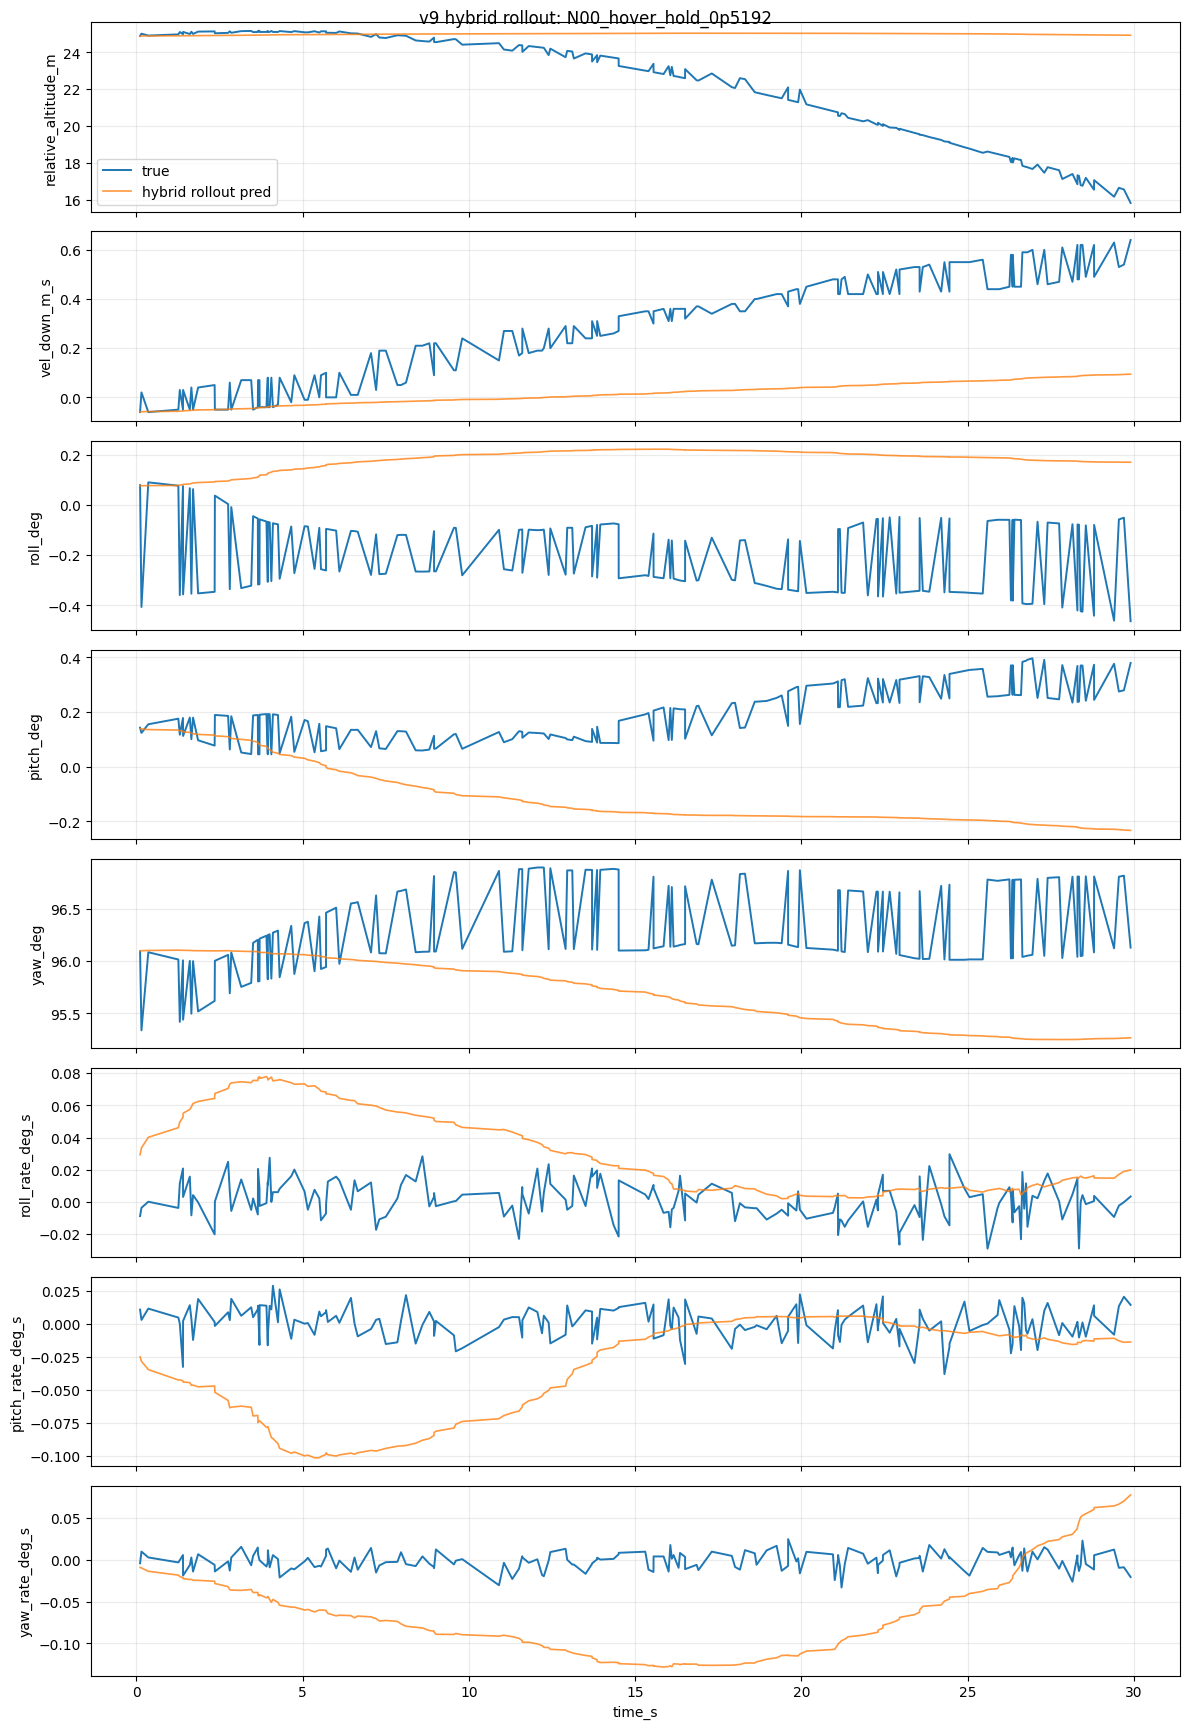

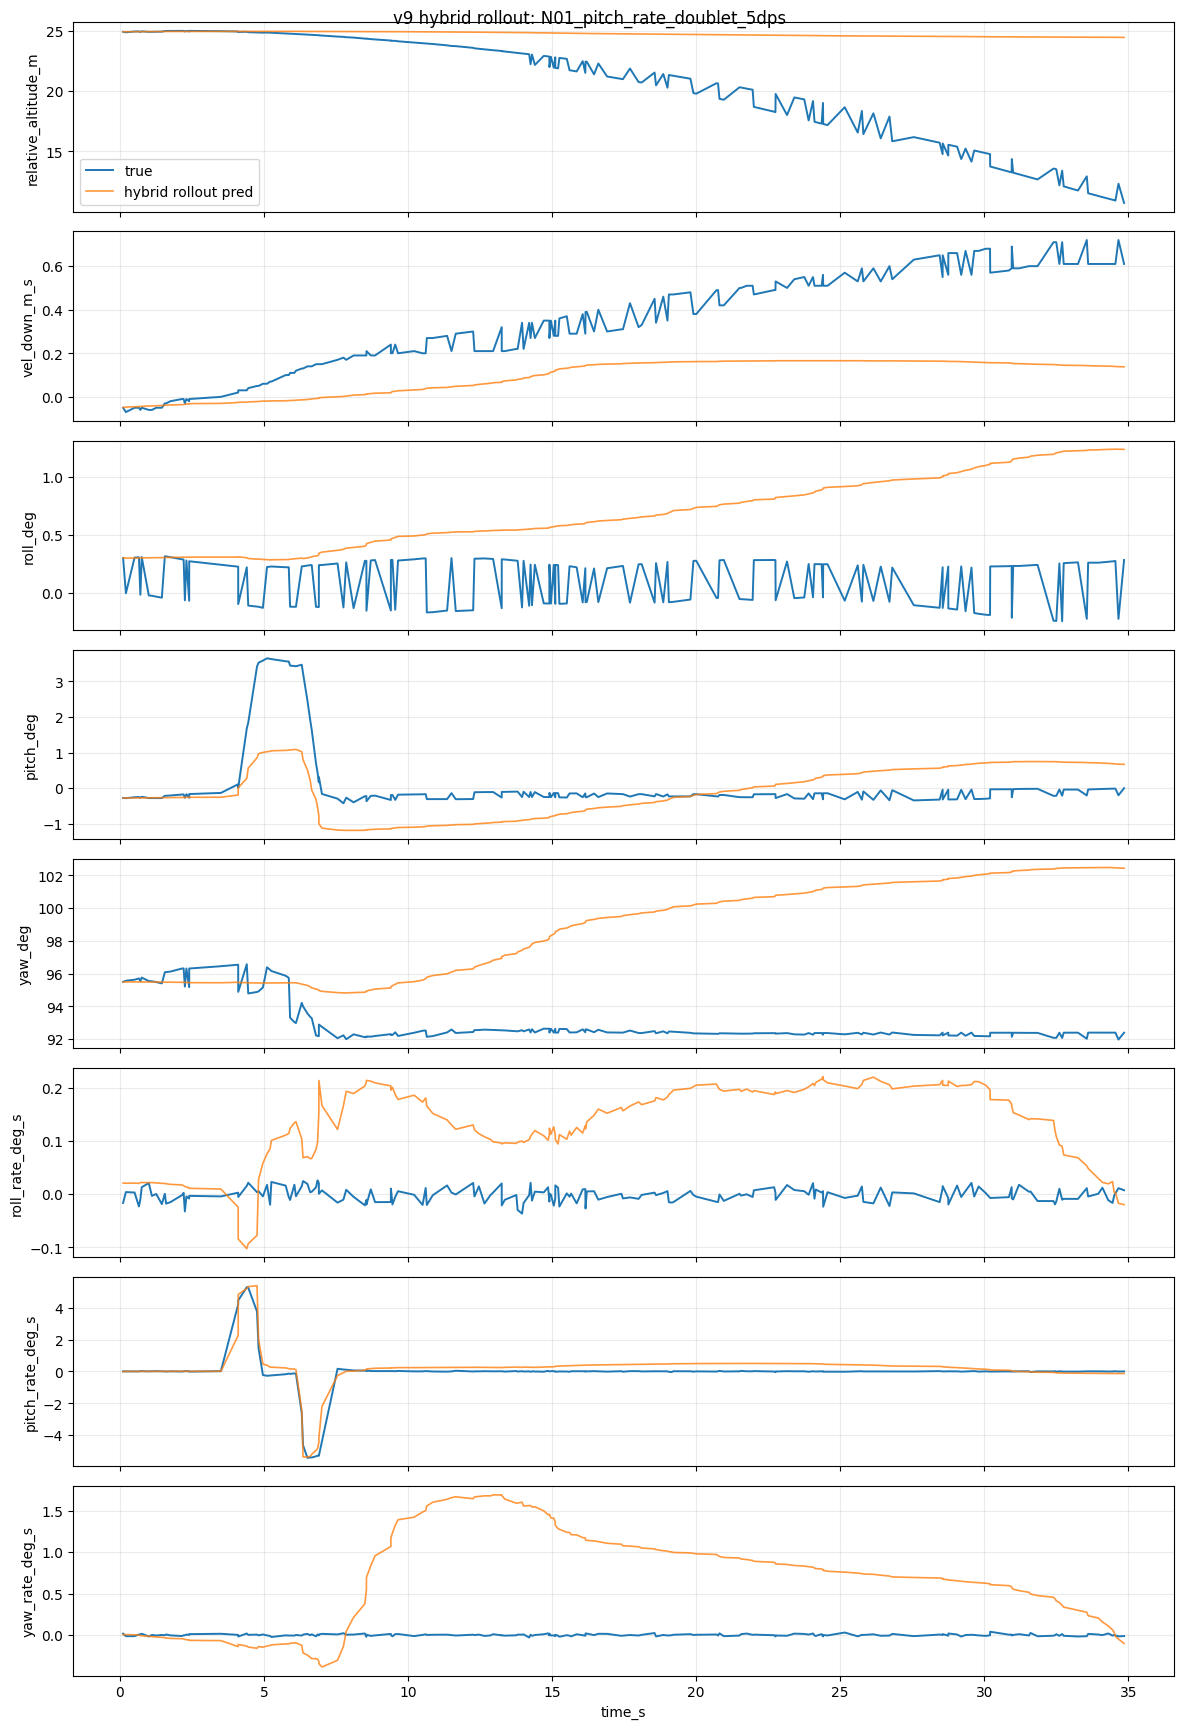

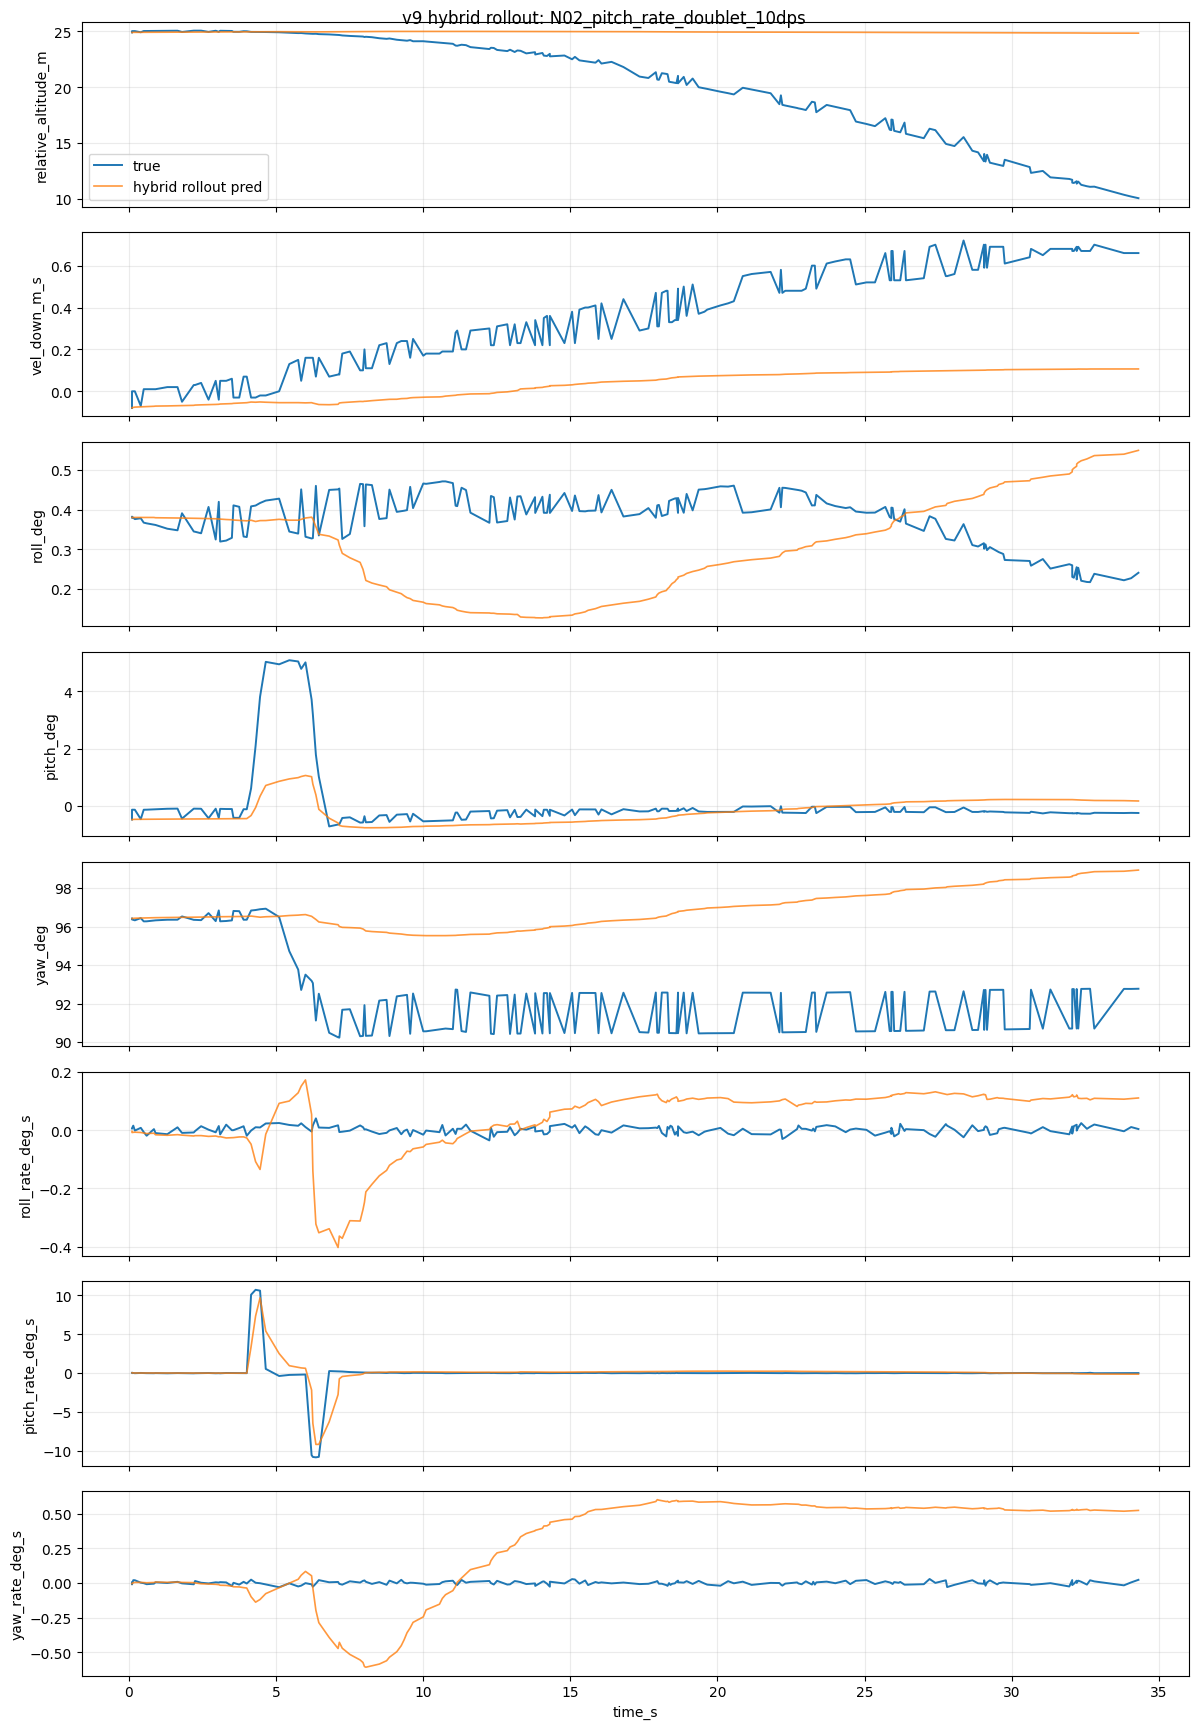

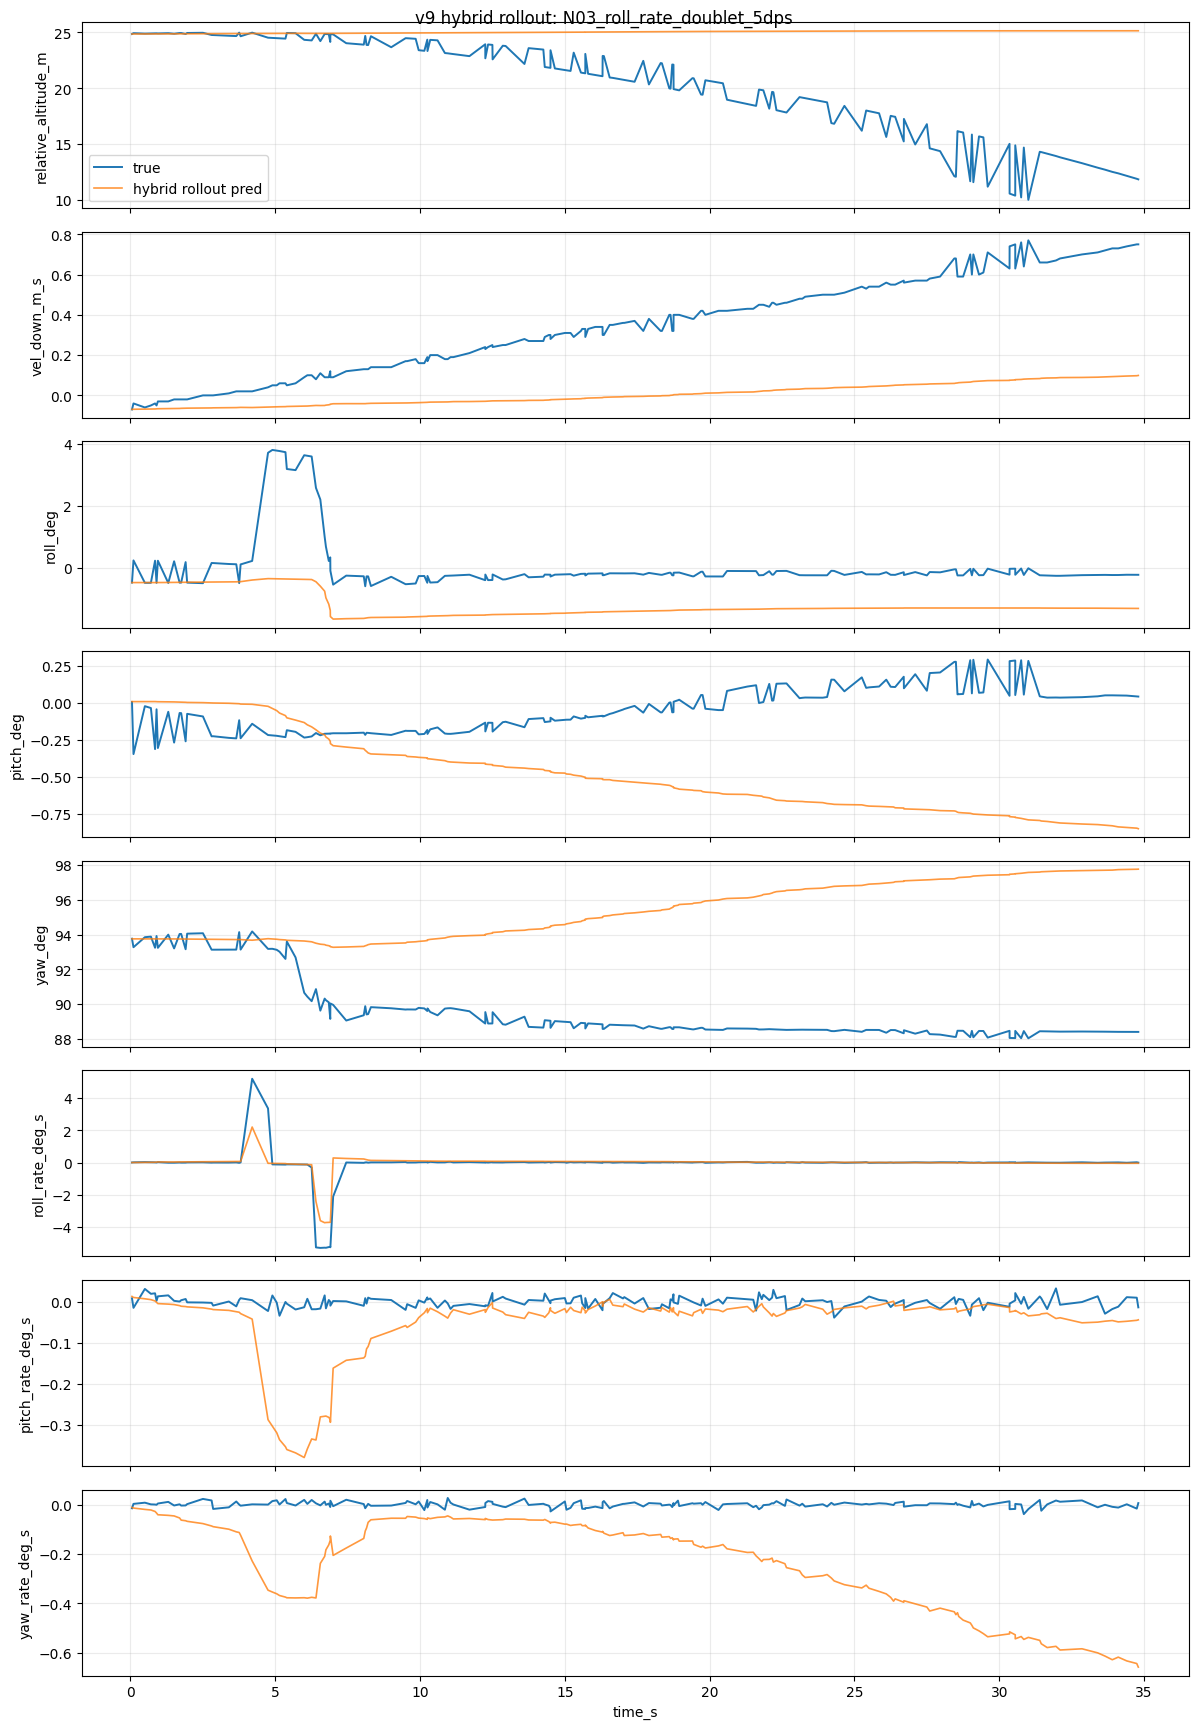

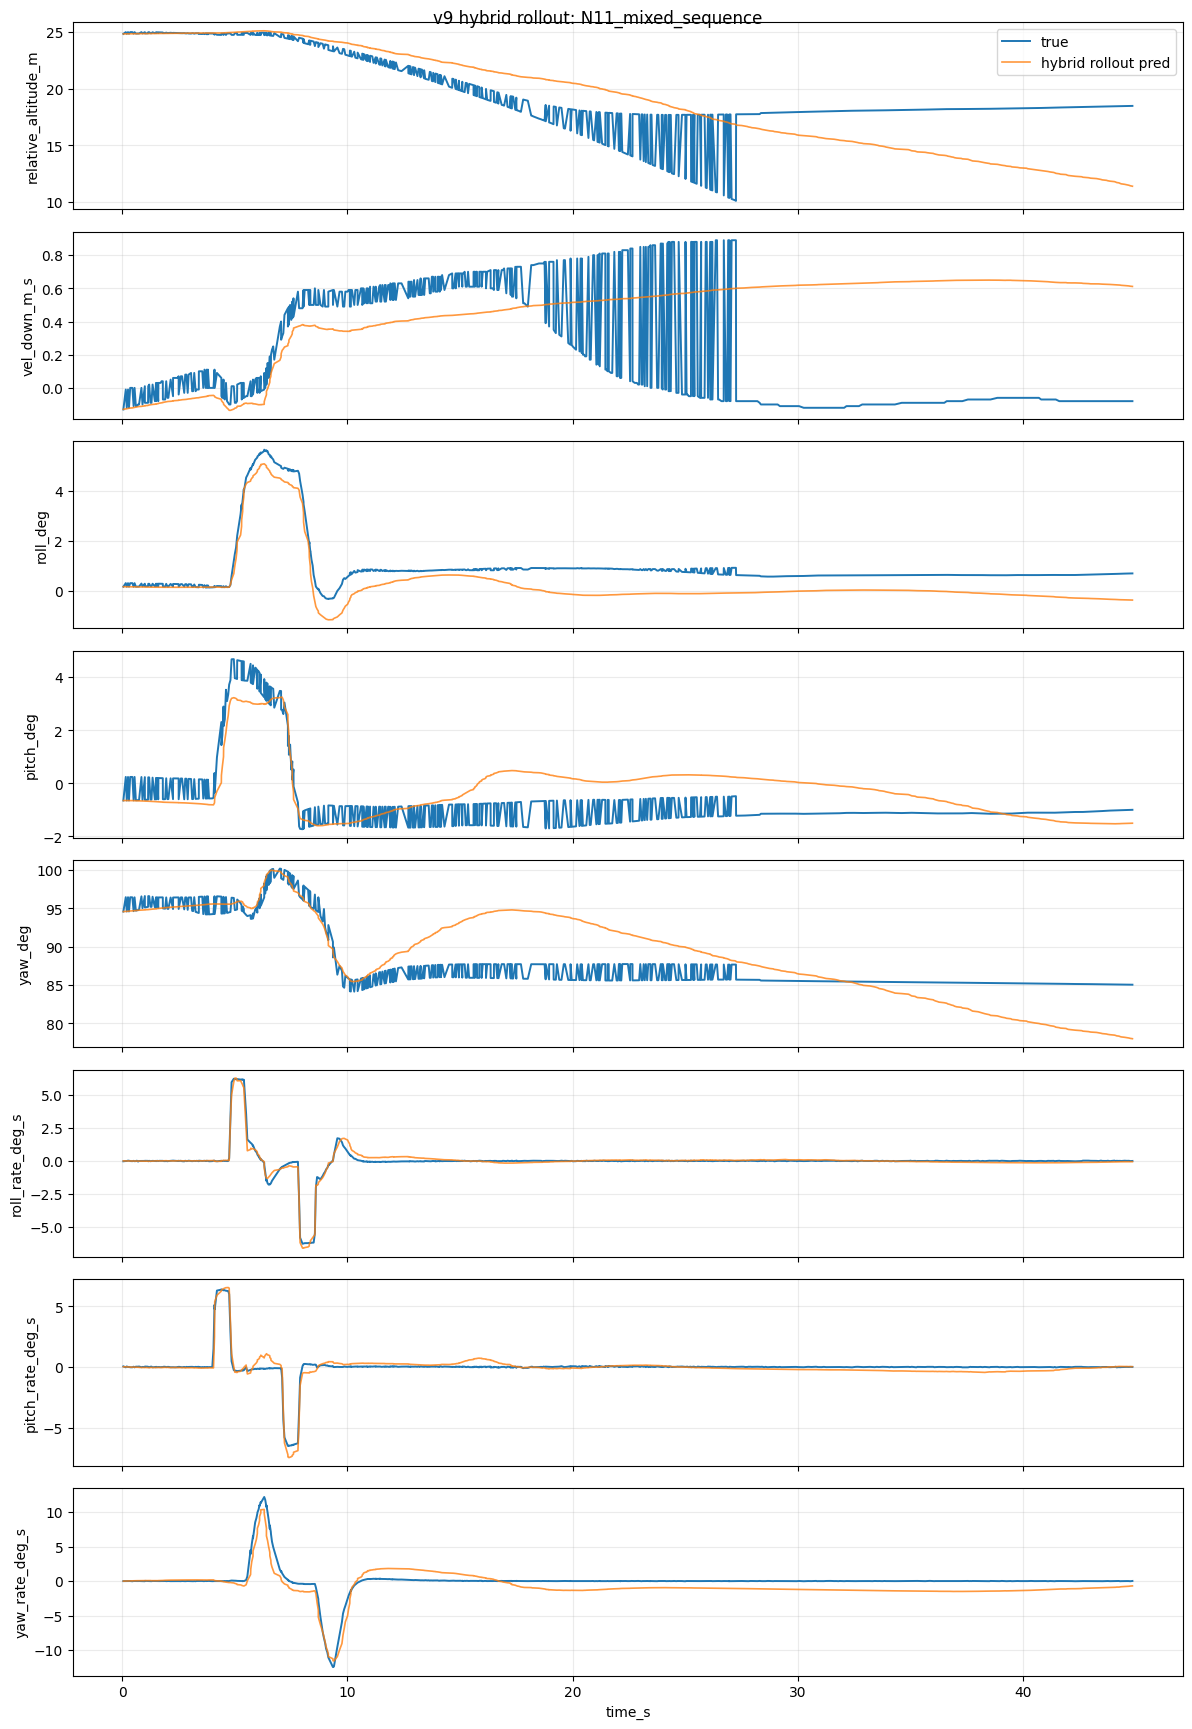

In [10]:
# Plot selected hybrid rollouts
def plot_rollout(df,scenario,max_steps=700):
    res=rollout_scenario(df,scenario,max_steps=max_steps,use_residual=True)
    if res is None:
        print('not enough rows',scenario); return
    _,sdf,pred,true_next=res; t=sdf['time_s'].to_numpy()
    plot_states=[s for s in ['relative_altitude_m','vel_down_m_s','roll_deg','pitch_deg','yaw_deg','roll_rate_rad_s','pitch_rate_rad_s','yaw_rate_rad_s'] if s in state_cols]
    fig,axes=plt.subplots(len(plot_states),1,figsize=(12,2.2*len(plot_states)),sharex=True)
    if len(plot_states)==1: axes=[axes]
    for ax,state in zip(axes,plot_states):
        j=state_cols.index(state); yt=true_next[:,j]; yp=pred[:,j]
        label=state
        if state.endswith('_rad_s'):
            yt=np.rad2deg(yt); yp=np.rad2deg(yp); label=state.replace('_rad_s','_deg_s')
        ax.plot(t,yt,label='true',lw=1.4); ax.plot(t,yp,label='hybrid rollout pred',lw=1.2,alpha=.8); ax.set_ylabel(label); ax.grid(True,alpha=.25)
    axes[0].legend(); axes[-1].set_xlabel('time_s'); fig.suptitle(f'v9 hybrid rollout: {scenario}'); plt.tight_layout(); plt.show()

for scenario in sorted(test_df['scenario'].unique())[:4]: plot_rollout(test_df,scenario)
if 'N11_mixed_sequence' in set(test_df['scenario']): plot_rollout(test_df,'N11_mixed_sequence')


In [11]:
# Save checkpoint
SAVE_ROOT=Path('/content/drive/MyDrive/PX4_Phase1_Models') if IN_COLAB else DATASET_PATH/'models'
SAVE_ROOT.mkdir(parents=True,exist_ok=True)
stamp=time.strftime('%Y%m%d_%H%M%S')
ckpt_path=SAVE_ROOT/f'px4_phase1_rate_dynamics_mlp_v9_hybrid_residual_{stamp}.pt'
checkpoint={
    'model_version':'px4_phase1_rate_dynamics_mlp_v9_hybrid_residual',
    'state_dict':model.state_dict(),
    'model_config':{'n_in':len(feature_cols),'n_core':len(core_cols),'n_dx':len(target_cols),**MODEL_CONFIG},
    'feature_cols':feature_cols,'core_cols':core_cols,'target_cols':target_cols,'state_cols':state_cols,'action_cols':action_cols,
    'x_scaler':x_scaler.to_dict(feature_cols),'core_scaler':core_scaler.to_dict(core_cols),'y_scaler':y_scaler.to_dict(target_cols),
    'residual_limits':RESIDUAL_LIMITS,
    'loss_config':{'core_data_weight':CORE_DATA_WEIGHT,'final_dx_weight':FINAL_DX_WEIGHT,'physics_dx_weight':PHYSICS_DX_WEIGHT,'residual_reg_weight':RESIDUAL_REG_WEIGHT},
    'dataset_path':str(DATASET_PATH),'metadata':metadata,'history':hist_df.to_dict(orient='records'),'one_step_metrics':metrics_df.to_dict(orient='records'),'physics_only_metrics':physics_metrics_df.to_dict(orient='records'),'core_metrics':core_metrics_df.to_dict(orient='records'),'residual_summary':residual_summary_df.to_dict(orient='records'),'rollout_metrics':rollout_metrics_df.to_dict(orient='records')
}
torch.save(checkpoint,ckpt_path)
print('saved:',ckpt_path)


saved: /content/drive/MyDrive/PX4_Phase1_Models/px4_phase1_rate_dynamics_mlp_v9_hybrid_residual_20260508_090821.pt


In [12]:
# Minimal load check
loaded=torch.load(ckpt_path,map_location='cpu')
print('loaded keys:',sorted(loaded.keys()))
print('feature/core/target:',len(loaded['feature_cols']),len(loaded['core_cols']),len(loaded['target_cols']))


loaded keys: ['action_cols', 'core_cols', 'core_metrics', 'core_scaler', 'dataset_path', 'feature_cols', 'history', 'loss_config', 'metadata', 'model_config', 'model_version', 'one_step_metrics', 'physics_only_metrics', 'residual_limits', 'residual_summary', 'rollout_metrics', 'state_cols', 'state_dict', 'target_cols', 'x_scaler', 'y_scaler']
feature/core/target: 23 6 10
